# Step 1 | Setup

## Step 1.1 | Importing Necessary Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from tabulate import tabulate
from collections import Counter

%matplotlib inline

In [2]:
# Configure Seaborn plot styles: Set background color and use dark grid
sns.set_theme(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')

## Step 1.2 | Loading the Dataset

In [3]:
df = pd.read_csv('Data/data.csv', encoding="ISO-8859-1")
df.shape

(541909, 8)

# Step 2 | Initial Data Analysis

## Step 2.1 | Dataset Overview

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## Step 2.2 | Summary Statistics

In [6]:
df['CustomerID'] = df['CustomerID'].astype(object)

In [7]:
# Summary statistics for numerical variables
df.describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [8]:
# Summary statistics for categorical variables
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,CustomerID,Country
count,541909,541909,540455,541909,406829.0,541909
unique,25900,4070,4223,23260,4372.0,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,17841.0,United Kingdom
freq,1114,2313,2369,1114,7983.0,495478


# Step 3 | Data Cleaning & Transformation

## Step 3.1 | Handling Missing Values

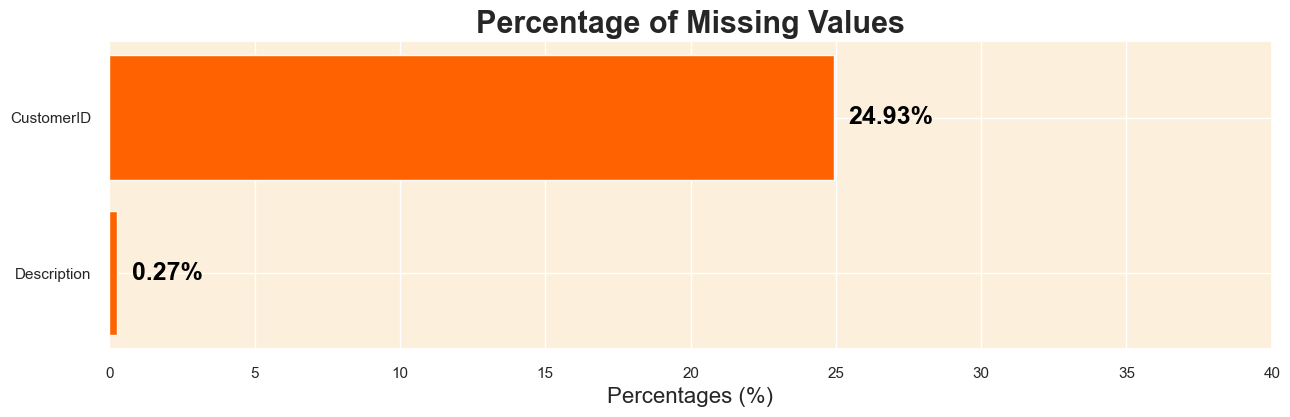

In [9]:
# Tính toán % mất mát dữ liệu
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

# Sắp xếp tỷ lệ mất mát
missing_percentage.sort_values(ascending=True, inplace=True)

# Vẽ biểu đồ thanh
fig, ax = plt.subplots(figsize=(15, 4))
ax.barh(missing_percentage.index, missing_percentage, color='#ff6200')

# Chú thích các giá trị và chỉ mục
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Đặt giới hạn trục x
ax.set_xlim([0, 40])

# Thêm tiêu đề và nhãn trục x
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [10]:
# Xóa bỏ các điểm mất mát dữ liệu ở 2 cột
df = df.dropna(subset=['CustomerID', 'Description'])
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.shape[0]

406829

## Step 3.2 | Handling Duplicates

In [12]:
# Tìm các hàng trùng lặp
duplicate_rows = df[df.duplicated(keep=False)]

# Sắp xếp dữ liệu theo các cột nhất định để thấy các hàng trùng lặp nằm cạnh nhau
duplicate_rows_sorted = duplicate_rows.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])

# Hiển thị 10 bản ghi đầu tiên
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [13]:
# Hiển thị số lượng các hàng trùng lặp
print(f"The dataset contains {df.duplicated().sum()} duplicate rows that need to be removed.")

# Loại bỏ các hàng trùng lặp
df.drop_duplicates(inplace=True)

The dataset contains 5225 duplicate rows that need to be removed.


In [14]:
# Lấy số lượng hàng trong dataframe
df.shape[0]

401604

## Step 3.3 | Correcting StockCode Anomalies

In [15]:
# Tìm số lượng mã sản phẩm duy nhất
unique_stock_codes = df['StockCode'].nunique()

# In ra mã sản phẩm duy nhất
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3684


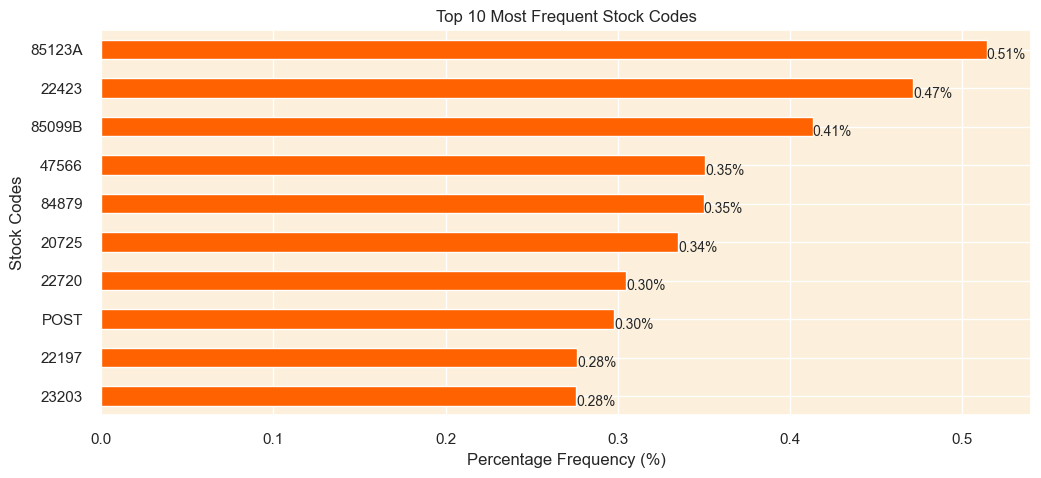

In [16]:
# Tìm 10 mã sản phẩm phổ biến nhất duy nhất
top_10_stock_codes = df['StockCode'].value_counts(normalize=True).head(10) * 100

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='#ff6200')

# Thêm %
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

In [17]:
# Tìm số ký tự số trong mỗi mã chứng khoán duy nhất
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# In số lượng giá trị cho mã chứng khoán duy nhất
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


In [18]:
# Tìm số ký tự số trong mỗi InvoiceNo duy nhất
unique_invoice_nos = df['InvoiceNo'].unique()
numeric_char_counts_in_unique_invoice_nos = pd.Series(unique_invoice_nos).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# In số lượng giá trị cho InvoiceNos duy nhất
print("Value counts of numeric character frequencies in unique InvoiceNos:")
print("-"*70)
print(numeric_char_counts_in_unique_invoice_nos)

Value counts of numeric character frequencies in unique InvoiceNos:
----------------------------------------------------------------------
6    22190
Name: count, dtype: int64


In [19]:
# Tìm và in mã chứng khoán có 0 và 1 ký tự số
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# In mỗi mã chứng khoán trên một dòng mới
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


In [20]:
# Tính toán phần trăm các bản ghi có mã chứng khoán này
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# In phần trăm
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.48%


In [21]:
# Xóa các hàng có mã chứng khoán bất thường khỏi tập dữ liệu
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

In [22]:
df.shape[0]

399689

## Step 3.4 | Cleaning Description Column

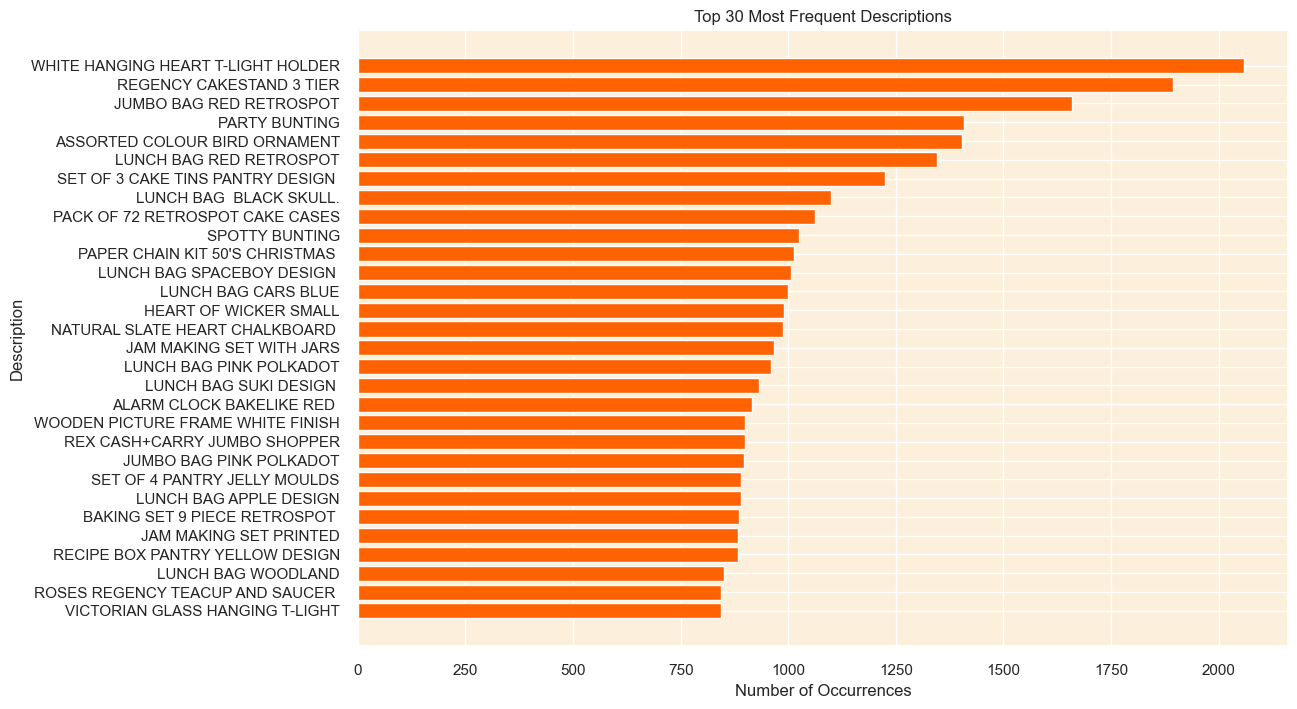

In [23]:
# Tính toán sự xuất hiện của mỗi mô tả duy nhất và sắp xếp chúng
description_counts = df['Description'].value_counts()

# Nhận 30 mô tả hàng đầu
top_30_descriptions = description_counts[:30]

# Vẽ sơ đồ
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='#ff6200')

# Thêm nhãn và tiêu đề
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')
plt.show()

In [24]:
# Tìm mô tả duy nhất có chứa các ký tự viết thường
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# In các mô tả duy nhất có chứa các ký tự viết thường
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


In [25]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Tính toán phần trăm các bản ghi có mô tả liên quan đến dịch vụ
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# In phần trăm các bản ghi có mô tả liên quan đến dịch vụ
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Xóa các hàng có thông tin liên quan đến dịch vụ trong phần mô tả
df = df[~df['Description'].isin(service_related_descriptions)]

# Chuẩn hóa văn bản thành chữ in hoa để duy trì tính đồng nhất trên toàn bộ tập dữ liệu
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [26]:
df.shape[0]

399606

## Step 3.5 | Treating Zero Unit Prices

In [27]:
df['UnitPrice'].describe()

count    399606.000000
mean          2.904957
std           4.448796
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: UnitPrice, dtype: float64

In [28]:
df[df['UnitPrice']==0].describe()[['Quantity']]

,Quantity
count,33.000000
mean,420.515152
std,2176.713608
min,1.000000
25%,2.000000
50%,11.000000
75%,36.000000
max,12540.000000


In [29]:
# Xóa các bản ghi có đơn giá bằng 0 để tránh các lỗi nhập dữ liệu tiềm ẩn
df = df[df['UnitPrice'] > 0]

## Step 3.6 | Treating Cancelled Transactions

In [30]:
# Lọc các hàng có InvoiceNo bắt đầu bằng "C" và tạo một cột mới cho biết trạng thái giao dịch
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')
df.loc[df['Transaction_Status'] == 'Cancelled', 'Quantity'] = 0

# Phân tích đặc điểm của các hàng này (xem xét cột mới)
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
# Xóa 'CustomerID' khỏi khung dữ liệu gốc trước khi tính toán số liệu thống kê mô tả
cancelled_transactions.drop(columns=['CustomerID'], inplace=False).describe()

,Quantity,UnitPrice
count,8505.0,8505.000000
mean,0.0,4.438907
std,0.0,9.198968
min,0.0,0.030000
25%,0.0,1.450000
50%,0.0,2.550000
75%,0.0,4.950000
max,0.0,295.000000


In [31]:
# Đặt 'Số lượng' thành 0 cho các giao dịch đã hủy
df.loc[df['Transaction_Status'] == 'Cancelled', 'Quantity'] = 0


In [32]:
# xuất file data_cleaned
df.to_csv('Data/data_cleaned.csv', index=False)

# Step 4 | Feature Engineering

## Step 4.1 | RFM Features

### Step 4.1.1 | Recency (R)

In [33]:
# Chuyển đổi InvoiceDate sang kiểu datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Chuyển đổi InvoiceDate thành datetime và chỉ trích xuất ngày
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Tìm ngày mua hàng gần đây nhất của mỗi khách hàng
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# Tìm ngày gần đây nhất trong toàn bộ tập dữ liệu
most_recent_date = df['InvoiceDay'].max()

# Chuyển đổi InvoiceDay sang kiểu datetime trước khi trừ
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

# Tính số ngày kể từ lần mua hàng cuối cùng của mỗi khách hàng
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Xóa cột InvoiceDay
customer_data.drop(columns=['InvoiceDay'], inplace=True)

In [34]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


### Step 4.1.2 | Frequency (F)

In [35]:
# Tính tổng số giao dịch được thực hiện bởi mỗi khách hàng
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)

# Tính tổng số sản phẩm được mua bởi mỗi khách hàng
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Gộp các tính năng mới vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,74215
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


### Step 4.1.3 | Monetary (M)

In [36]:
# Tính tổng chi tiêu của mỗi khách hàng
df['Total_Spend'] = df['UnitPrice'] * df['Quantity']
total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

# Tính giá trị giao dịch trung bình cho mỗi khách hàng
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Gộp các tính năng mới vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, total_spend, on='CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on='CustomerID')

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,74215,77183.60,38591.800000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


## Step 4.2 | Product Diversity

In [37]:
# Tính số lượng sản phẩm duy nhất được mỗi khách hàng mua
unique_products_purchased = df.groupby('CustomerID')['StockCode'].nunique().reset_index()
unique_products_purchased.rename(columns={'StockCode': 'Unique_Products_Purchased'}, inplace=True)

# Gộp tính năng mới vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, unique_products_purchased, on='CustomerID')

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased
0,12346.0,325,2,74215,77183.60,38591.800000,1
1,12347.0,2,7,2458,4310.00,615.714286,103
2,12348.0,75,4,2332,1437.24,359.310000,21
3,12349.0,18,1,630,1457.55,1457.550000,72
4,12350.0,310,1,196,294.40,294.400000,16


## Step 4.3 | Behavioral Features

In [38]:
# Trích xuất ngày trong tuần và giờ từ InvoiceDate
df['Day_Of_Week'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

# Tính số ngày trung bình giữa các lần mua hàng liên tiếp
days_between_purchases = df.groupby('CustomerID')['InvoiceDay'].apply(lambda x: (x.diff().dropna()).apply(lambda y: y.days))
average_days_between_purchases = days_between_purchases.groupby('CustomerID').mean().reset_index()
average_days_between_purchases.rename(columns={'InvoiceDay': 'Average_Days_Between_Purchases'}, inplace=True)

# Tìm ngày mua sắm yêu thích trong tuần
favorite_shopping_day = df.groupby(['CustomerID', 'Day_Of_Week']).size().reset_index(name='Count')
favorite_shopping_day = favorite_shopping_day.loc[favorite_shopping_day.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Day_Of_Week']]

# Tìm giờ mua sắm yêu thích trong ngày
favorite_shopping_hour = df.groupby(['CustomerID', 'Hour']).size().reset_index(name='Count')
favorite_shopping_hour = favorite_shopping_hour.loc[favorite_shopping_hour.groupby('CustomerID')['Count'].idxmax()][['CustomerID', 'Hour']]

# Gộp các tính năng mới vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, average_days_between_purchases, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_day, on='CustomerID')
customer_data = pd.merge(customer_data, favorite_shopping_hour, on='CustomerID')

# Cập nhật 'Average_Days_Between_Purchases' thành 700 cho các hàng đó
zero_avg_days = customer_data[customer_data['Average_Days_Between_Purchases'] == 0]
customer_data.loc[zero_avg_days.index, 'Average_Days_Between_Purchases'] = 700

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour
0,12346.0,325,2,74215,77183.60,38591.800000,1,700,1,10
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19
3,12349.0,18,1,630,1457.55,1457.550000,72,700,0,9
4,12350.0,310,1,196,294.40,294.400000,16,700,2,16


## Step 4.4 | Geographic Features

In [39]:
df['Country'].value_counts(normalize=True).head()

Country
United Kingdom    0.890971
Germany           0.022722
France            0.020402
EIRE              0.018440
Spain             0.006162
Name: proportion, dtype: float64

In [40]:
# Nhóm theo CustomerID và Quốc gia để lấy số lượng giao dịch theo quốc gia cho mỗi khách hàng
customer_country = df.groupby(['CustomerID', 'Country']).size().reset_index(name='Number_of_Transactions')

# Lấy quốc gia có số lượng giao dịch tối đa cho mỗi khách hàng (trong trường hợp một khách hàng có giao dịch từ nhiều quốc gia)
customer_main_country = customer_country.sort_values('Number_of_Transactions', ascending=False).drop_duplicates('CustomerID')

# Tạo một cột nhị phân cho biết khách hàng có đến từ Vương quốc Anh hay không
customer_main_country['Is_UK'] = customer_main_country['Country'].apply(lambda x: 1 if x == 'United Kingdom' else 0)

# Hợp nhất dữ liệu này với khung dữ liệu customer_data của chúng tôi
customer_data = pd.merge(customer_data, customer_main_country[['CustomerID', 'Is_UK']], on='CustomerID', how='left')

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK
0,12346.0,325,2,74215,77183.60,38591.800000,1,700,1,10,1
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0
3,12349.0,18,1,630,1457.55,1457.550000,72,700,0,9,0
4,12350.0,310,1,196,294.40,294.400000,16,700,2,16,0


In [41]:
# Hiển thị phân phối
customer_data['Is_UK'].value_counts()

Is_UK
1    3866
0     416
Name: count, dtype: int64

## Step 4.5 | Cancellation Insights

In [42]:
# Tính tổng số giao dịch được thực hiện bởi mỗi khách hàng
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

# Tính toán số lượng giao dịch bị hủy của mỗi khách hàng
cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancellation_frequency = cancelled_transactions.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
cancellation_frequency.rename(columns={'InvoiceNo': 'Cancellation_Frequency'}, inplace=True)

# Hợp nhất dữ liệu Tần suất hủy vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, cancellation_frequency, on='CustomerID', how='left')

# Thay thế giá trị NaN bằng 0 (đối với khách hàng chưa hủy bất kỳ giao dịch nào)
customer_data['Cancellation_Frequency'] = customer_data['Cancellation_Frequency'].fillna(0)

# Tính tỷ lệ hủy bỏ
customer_data['Cancellation_Rate'] = customer_data['Cancellation_Frequency'] / total_transactions['InvoiceNo']

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate
0,12346.0,325,2,74215,77183.60,38591.800000,1,700,1,10,1,1.0,0.5
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0,0.0,0.0
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0,0.0,0.0
3,12349.0,18,1,630,1457.55,1457.550000,72,700,0,9,0,0.0,0.0
4,12350.0,310,1,196,294.40,294.400000,16,700,2,16,0,0.0,0.0


## Step 4.6 | Seasonality & Trends

In [45]:
# Trích xuất tháng và năm từ InvoiceDate
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Tính toán chi tiêu hàng tháng cho mỗi khách hàng
monthly_spending = df.groupby(['CustomerID', 'Year', 'Month'])['Total_Spend'].sum().reset_index()

# Tính toán các mẫu mua theo mùa: Chúng tôi sử dụng tần suất hàng tháng làm đại diện cho các mẫu mua theo mùa
seasonal_buying_patterns = monthly_spending.groupby('CustomerID')['Total_Spend'].agg(['mean', 'std']).reset_index()
seasonal_buying_patterns.rename(columns={'mean': 'Monthly_Spending_Mean', 'std': 'Monthly_Spending_Std'}, inplace=True)

# Thay thế giá trị NaN trong Monthly_Spending_Std bằng 0, ngụ ý không có sự thay đổi đối với khách hàng có tháng giao dịch duy nhất
seasonal_buying_patterns['Monthly_Spending_Std'] = seasonal_buying_patterns['Monthly_Spending_Std'].fillna(0)

# Tính toán xu hướng chi tiêu
# Chúng tôi đang sử dụng độ dốc của đường xu hướng tuyến tính phù hợp với chi tiêu của khách hàng theo thời gian như một chỉ báo về xu hướng chi tiêu
def calculate_trend(spend_data):
    # Nếu có nhiều hơn một điểm dữ liệu, chúng tôi tính toán xu hướng bằng hồi quy tuyến tính
    if len(spend_data) > 1:
        x = np.arange(len(spend_data))
        slope, _, _, _, _ = linregress(x, spend_data)
        return slope
    # Nếu chỉ có một điểm dữ liệu, không có xu hướng nào có thể được tính toán, do đó chúng tôi trả về 0
    else:
        return 0

# Áp dụng hàm calculate_trend để tìm xu hướng chi tiêu cho từng khách hàng
spending_trends = monthly_spending.groupby('CustomerID')['Total_Spend'].apply(calculate_trend).reset_index()
spending_trends.rename(columns={'Total_Spend': 'Spending_Trend'}, inplace=True)

# Gộp các tính năng mới vào khung dữ liệu customer_data
customer_data = pd.merge(customer_data, seasonal_buying_patterns, on='CustomerID')
customer_data = pd.merge(customer_data, spending_trends, on='CustomerID')

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,2,74215,77183.60,38591.800000,1,700,1,10,1,1.0,0.5,77183.600000,0.000000,0.000000
1,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0,0.0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0,0.0,0.0,359.310000,203.875689,-100.884000
3,12349.0,18,1,630,1457.55,1457.550000,72,700,0,9,0,0.0,0.0,1457.550000,0.000000,0.000000
4,12350.0,310,1,196,294.40,294.400000,16,700,2,16,0,0.0,0.0,294.400000,0.000000,0.000000


In [46]:
# Thay đổi kiểu dữ liệu của 'CustomerID' thành chuỗi vì đây là mã định danh duy nhất và không được sử dụng trong các phép toán
customer_data['CustomerID'] = customer_data['CustomerID'].astype(str)

# Chuyển đổi kiểu dữ liệu của các cột thành kiểu tối ưu
customer_data = customer_data.convert_dtypes()

In [47]:
customer_data.head(10)

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12346.0,325,2,74215,77183.6,38591.8,1,700.0,1,10,1,1,0.5,77183.6,0.0,0.0
1,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071
2,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884
3,12349.0,18,1,630,1457.55,1457.55,72,700.0,0,9,0,0,0.0,1457.55,0.0,0.0
4,12350.0,310,1,196,294.4,294.4,16,700.0,2,16,0,0,0.0,294.4,0.0,0.0
5,12352.0,36,8,526,1385.74,173.2175,57,3.13253,1,14,0,1,0.125,346.435,120.042154,-2.682
6,12353.0,204,1,20,89.0,89.0,4,700.0,3,17,0,0,0.0,89.0,0.0,0.0
7,12354.0,232,1,530,1079.4,1079.4,58,700.0,3,13,0,0,0.0,1079.4,0.0,0.0
8,12355.0,214,1,240,459.4,459.4,13,700.0,0,13,0,0,0.0,459.4,0.0,0.0
9,12356.0,22,3,1573,2487.43,829.143333,52,5.315789,1,9,0,0,0.0,829.143333,991.462585,-944.635


In [48]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4282 non-null   string 
 1   Days_Since_Last_Purchase        4282 non-null   Int64  
 2   Total_Transactions              4282 non-null   Int64  
 3   Total_Products_Purchased        4282 non-null   Int64  
 4   Total_Spend                     4282 non-null   Float64
 5   Average_Transaction_Value       4282 non-null   Float64
 6   Unique_Products_Purchased       4282 non-null   Int64  
 7   Average_Days_Between_Purchases  4282 non-null   Float64
 8   Day_Of_Week                     4282 non-null   Int32  
 9   Hour                            4282 non-null   Int32  
 10  Is_UK                           4282 non-null   Int64  
 11  Cancellation_Frequency          4282 non-null   Int64  
 12  Cancellation_Rate               4282 non-null

# Step 5 | Outlier Detection and Treatment

In [49]:
# Khởi tạo mô hình IsolationForest với tham số ô nhiễm là 0,05
model = IsolationForest(contamination=0.05, random_state=0)

# Phù hợp mô hình với tập dữ liệu của chúng tôi (chuyển đổi DataFrame sang NumPy để tránh cảnh báo)
customer_data['Outlier_Scores'] = model.fit_predict(customer_data.iloc[:, 1:].to_numpy())

# Tạo một cột mới để xác định các giá trị ngoại lai (1 cho các giá trị nội tại và -1 cho các giá trị ngoại lai)
customer_data['Is_Outlier'] = [1 if x == -1 else 0 for x in customer_data['Outlier_Scores']]

# Hiển thị một vài hàng đầu tiên của khung dữ liệu customer_data
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,Outlier_Scores,Is_Outlier
0,12346.0,325,2,74215,77183.6,38591.8,1,700.0,1,10,1,1,0.5,77183.6,0.0,0.0,-1,1
1,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071,1,0
2,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884,1,0
3,12349.0,18,1,630,1457.55,1457.55,72,700.0,0,9,0,0,0.0,1457.55,0.0,0.0,-1,1
4,12350.0,310,1,196,294.4,294.4,16,700.0,2,16,0,0,0.0,294.4,0.0,0.0,1,0


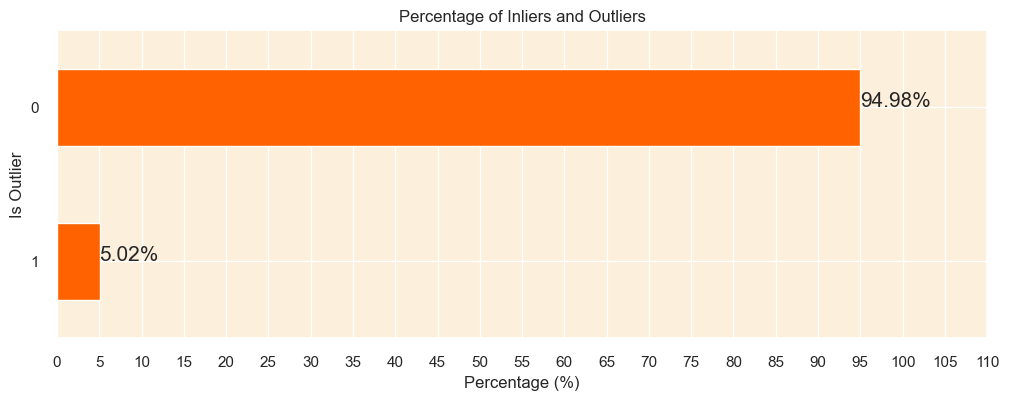

In [50]:
# Tính phần trăm của các giá trị nội tại và ngoại tại
outlier_percentage = customer_data['Is_Outlier'].value_counts(normalize=True) * 100

# Vẽ biểu đồ phần trăm các giá trị nội tại và ngoại tại
plt.figure(figsize=(12, 4))
outlier_percentage.plot(kind='barh', color='#ff6200')

# Thêm nhãn phần trăm vào các thanh
for index, value in enumerate(outlier_percentage):
    plt.text(value, index, f'{value:.2f}%', fontsize=15)

plt.title('Percentage of Inliers and Outliers')
plt.xticks(ticks=np.arange(0, 115, 5))
plt.xlabel('Percentage (%)')
plt.ylabel('Is Outlier')
plt.gca().invert_yaxis()
plt.show()

In [51]:
# Tách các giá trị ngoại lệ để phân tích
outliers_data = customer_data[customer_data['Is_Outlier'] == 1]

# Xóa các giá trị ngoại lai khỏi tập dữ liệu chính
customer_data_cleaned = customer_data[customer_data['Is_Outlier'] == 0]

# Xóa các cột 'Outlier_Scores' và 'Is_Outlier'
customer_data_cleaned = customer_data_cleaned.drop(columns=['Outlier_Scores', 'Is_Outlier'])

# Đặt lại chỉ mục của dữ liệu đã được làm sạch
customer_data_cleaned.reset_index(drop=True, inplace=True)

In [52]:
# Lấy số hàng trong tập dữ liệu khách hàng đã được dọn dẹp
customer_data_cleaned.shape[0]

4067

In [53]:
customer_data_cleaned.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,2,7,2458,4310.0,615.714286,103,2.016575,1,14,0,0,0.0,615.714286,341.070789,4.486071
1,12348.0,75,4,2332,1437.24,359.31,21,10.884615,3,19,0,0,0.0,359.31,203.875689,-100.884
2,12350.0,310,1,196,294.4,294.4,16,700.0,2,16,0,0,0.0,294.4,0.0,0.0
3,12352.0,36,8,526,1385.74,173.2175,57,3.13253,1,14,0,1,0.125,346.435,120.042154,-2.682
4,12353.0,204,1,20,89.0,89.0,4,700.0,3,17,0,0,0.0,89.0,0.0,0.0


In [54]:
# xuất file customer_data_cleaned ra csv
customer_data_cleaned.to_csv('Data/customer_data_cleaned.csv', index=False)


# Step 6 | Correlation Analysis

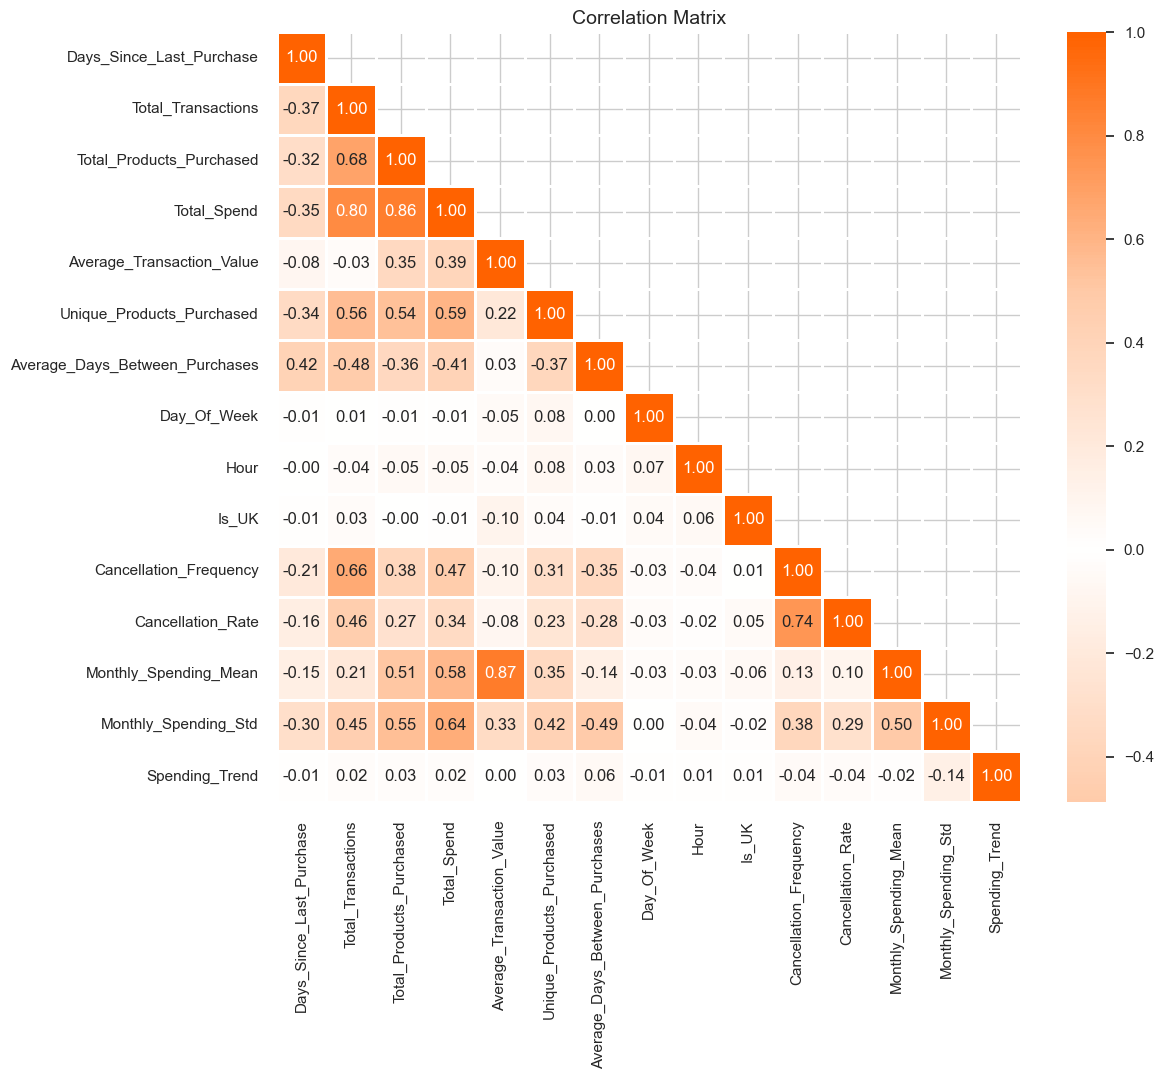

In [55]:
# Đặt lại kiểu nền
sns.set_style('whitegrid')

# Tính toán ma trận tương quan loại trừ cột 'CustomerID'
corr = customer_data_cleaned.drop(columns=['CustomerID']).corr()

# Xác định một bản đồ màu tùy chỉnh
colors = ['#ff6200', '#ffcaa8', 'white', '#ffcaa8', '#ff6200']
my_cmap = LinearSegmentedColormap.from_list('custom_map', colors, N=256)

# Tạo mặt nạ để chỉ hiển thị tam giác dưới của ma trận (vì nó được phản chiếu xung quanh đường chéo
# từ trên cùng bên trái xuống dưới cùng bên phải)
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True

# Vẽ bản đồ nhiệt
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap=my_cmap, annot=True, center=0, fmt='.2f', linewidths=2)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

# Step 7 | Feature Scaling

In [56]:
# Khởi tạo StandardScaler
scaler = StandardScaler()

# Danh sách các cột không cần phải thu nhỏ
columns_to_exclude = ['CustomerID', 'Is_UK', 'Day_Of_Week']

# Danh sách các cột cần được thu nhỏ
columns_to_scale = customer_data_cleaned.columns.difference(columns_to_exclude)

# Sao chép tập dữ liệu đã được làm sạch
customer_data_scaled = customer_data_cleaned.copy()

# Áp dụng bộ chia tỷ lệ cho các cột cần thiết trong tập dữ liệu
customer_data_scaled[columns_to_scale] = scaler.fit_transform(customer_data_scaled[columns_to_scale])

# Hiển thị một vài hàng đầu tiên của dữ liệu được chia tỷ lệ
customer_data_scaled.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend
0,12347.0,-0.901948,0.676144,1.858486,2.272697,1.643913,0.786896,-0.686409,1,0.646315,0,-0.538203,-0.425202,1.023038,1.249796,0.112020
1,12348.0,-0.165471,-0.018094,1.725640,0.213860,0.364181,-0.569888,-0.658942,3,2.815097,0,-0.538203,-0.425202,0.008712,0.458717,-0.490657
2,12350.0,2.205381,-0.712332,-0.526424,-0.605186,0.040211,-0.652618,1.475518,2,1.513828,0,-0.538203,-0.425202,-0.248070,-0.716848,0.086361
3,12352.0,-0.558931,0.907556,-0.178492,0.176951,-0.564619,0.025773,-0.682953,1,0.646315,0,0.383427,-0.225534,-0.042221,-0.024674,0.071021
4,12353.0,1.135976,-0.712332,-0.711987,-0.752391,-0.984954,-0.851172,1.475518,3,1.947585,0,-0.538203,-0.425202,-1.060625,-0.716848,0.086361


In [57]:
customer_data_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 4067 entries, 0 to 4066
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   CustomerID                      4067 non-null   string 
 1   Days_Since_Last_Purchase        4067 non-null   float64
 2   Total_Transactions              4067 non-null   float64
 3   Total_Products_Purchased        4067 non-null   float64
 4   Total_Spend                     4067 non-null   float64
 5   Average_Transaction_Value       4067 non-null   float64
 6   Unique_Products_Purchased       4067 non-null   float64
 7   Average_Days_Between_Purchases  4067 non-null   float64
 8   Day_Of_Week                     4067 non-null   Int32  
 9   Hour                            4067 non-null   float64
 10  Is_UK                           4067 non-null   Int64  
 11  Cancellation_Frequency          4067 non-null   float64
 12  Cancellation_Rate               4067 non-null

In [59]:
# xuất file customer_data_scaled ra csv
customer_data_scaled.to_csv('Data/customer_data_scaled.csv', index=False)

In [60]:
customer_data_scaled.shape

(4067, 16)

# Step 8 | Dimensionality Reduction

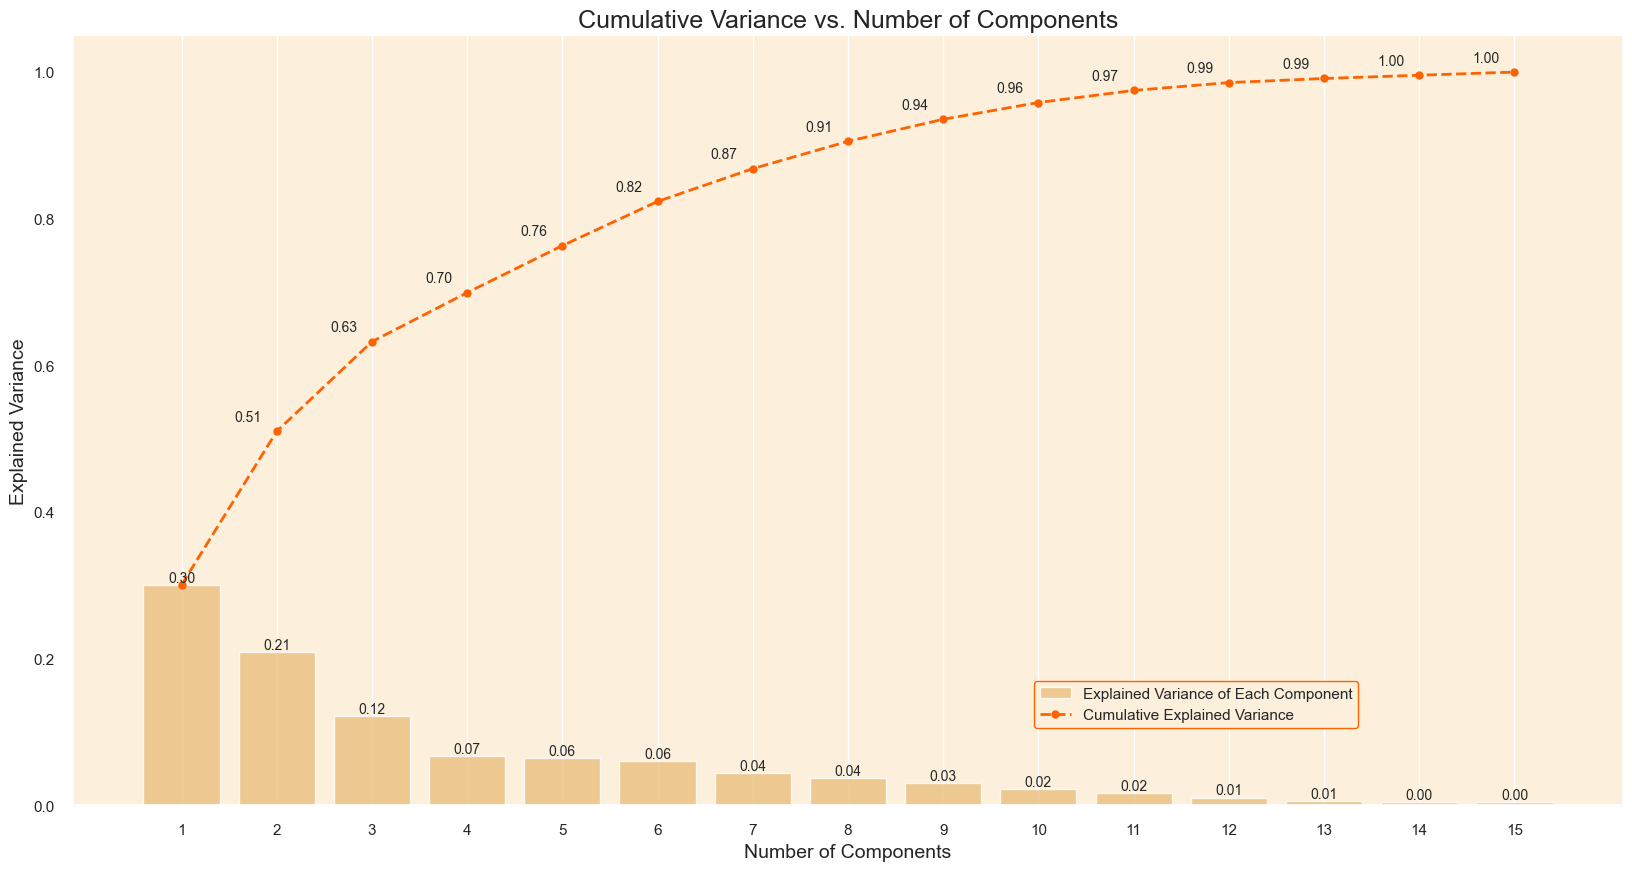

In [61]:
# Sử dụng 'CustomerID' làm index
customer_data_scaled.set_index('CustomerID', inplace=True)
# Áp dụng PCA
pca = PCA().fit(customer_data_scaled)

# Tính tổng tích lũy của phương sai đã giải thích
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Thiết lập phong cách cốt truyện seaborn
sns.set_theme(rc={'axes.facecolor': '#fcf0dc'}, style='darkgrid')

# Vẽ biểu đồ phương sai tích lũy được giải thích so với số lượng thành phần
plt.figure(figsize=(20, 10))

# Biểu đồ thanh cho sự thay đổi được giải thích của từng thành phần
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)),
                      y=explained_variance_ratio,
                      color='#fcc36d',
                      alpha=0.8)

# Biểu đồ đường thẳng cho phương sai tích lũy được giải thích
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance,
                     marker='o', linestyle='--', color='#ff6200', linewidth=2)

# Đặt nhãn và tiêu đề
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

# Tùy chỉnh các dấu tích và chú giải
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot],
           labels=['Explained Variance of Each Component', 'Cumulative Explained Variance'],
           loc=(0.62, 0.1),
           frameon=True,
           framealpha=1.0,
           edgecolor='#ff6200')

# Hiển thị các giá trị phương sai cho cả hai biểu đồ trên các ô
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')
plt.show()

In [62]:
pca = PCA(n_components=6)

# Điều chỉnh và chuyển đổi dữ liệu gốc sang khung dữ liệu PCA mới
customer_data_pca = pca.fit_transform(customer_data_scaled)

# Tạo một khung dữ liệu mới từ khung dữ liệu PCA, với các cột được gắn nhãn PC1, PC2, v.v.
customer_data_pca = pd.DataFrame(customer_data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# Thêm chỉ mục CustomerID trở lại khung dữ liệu PCA mới
customer_data_pca.index = customer_data_scaled.index

In [63]:
# Hiển thị khung dữ liệu kết quả dựa trên PC
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerID,,,,,,
12347.0,3.216448,-1.479686,1.972139,1.091774,-0.505431,0.264377
12348.0,0.659357,0.586927,0.653150,1.049354,-1.013580,2.190523
12350.0,-2.350524,-0.568342,0.673564,-0.330117,1.086585,1.858286
12352.0,0.605909,-1.460041,-0.856529,0.815976,-0.474489,0.344381
12353.0,-2.722626,0.509585,-0.437499,0.373808,0.490735,1.860667


In [64]:
# Đặt lại chỉ mục để biến 'CustomerID' thành một cột thông thường
customer_data_pca = customer_data_pca.reset_index()

# Di chuyển 'CustomerID' vào cột đầu tiên
customer_id_column = customer_data_pca.pop('CustomerID')
customer_data_pca.insert(0, 'CustomerID', customer_id_column)

# Hiển thị DataFrame đã cập nhật
customer_data_pca.head()


,CustomerID,PC1,PC2,PC3,PC4,PC5,PC6
0,12347.0,3.216448,-1.479686,1.972139,1.091774,-0.505431,0.264377
1,12348.0,0.659357,0.586927,0.653150,1.049354,-1.013580,2.190523
2,12350.0,-2.350524,-0.568342,0.673564,-0.330117,1.086585,1.858286
3,12352.0,0.605909,-1.460041,-0.856529,0.815976,-0.474489,0.344381
4,12353.0,-2.722626,0.509585,-0.437499,0.373808,0.490735,1.860667


In [66]:
# xuất file customer_data_pca ra csv
customer_data_pca.to_csv('Data/customer_data_pca.csv', index=False)